# Capstone — Predicting Future Content Performance Decline

**Lane:** Refresh / Content Opportunity Scoring

**Research question:** Can historical search-performance signals available before a prediction date rank content items that are most likely to experience a meaningful decline in the following month?

**Decision supported:** If editorial review capacity is limited, which content items should be investigated first?

This is the final warehouse-based experiment. It uses the FlyRank full pseudonymized warehouse, constructs a genuine future-window label, compares a transparent baseline with ML, and produces a ranked review queue.

**Public-safe framing:** this is predictive ranking / decision support. It does not establish that refreshing content causes recovery and does not claim to predict Google's algorithm.

## 1. Research design

For each content item at prediction month **T0**:

```text
previous 3 monthly observations
          ↓
         T0
          ↓
next calendar month
          ↓
future decline label
```

Features are constructed only from months before T0. The target is:

> `future_decline = 1` when next-month impressions are at least 20% below the immediately preceding month's impressions.

The 20% threshold is an operational research threshold, not a universal business rule. A 10% / 20% / 30% sensitivity check is included.

The query-level 90-day snapshot is deliberately excluded from the model because its historical availability cannot be established for every prediction point without additional dated snapshots.

In [1]:
%pip -q install -U duckdb huggingface_hub pyarrow scikit-learn matplotlib pandas numpy requests

import os, getpass, json, shutil, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, hf_hub_download

# Authentication: keep the token out of the notebook/repository.
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass("Hugging Face READ token: ")
if not HF_TOKEN:
    raise ValueError("A Hugging Face read token is required.")

REPO_ID = "FlyRank/internship-warehouse"
REPO_TYPE = "dataset"
PARTITION_ROOT = "fact_content_daily_performance"

# IMPORTANT:
# We do not use DuckDB's hf:// filesystem here. On some Windows environments,
# DuckDB's Hugging Face tree/API request can fail with an SSL connect error even
# though normal HTTPS access to huggingface.co works.
#
# Instead, Hugging Face Hub handles authentication/file discovery and downloads
# only the monthly performance partitions that this capstone needs. DuckDB then
# performs the actual aggregation locally. The raw warehouse is never committed.
api = HfApi(token=HF_TOKEN)
con = duckdb.connect()

print("DuckDB:", duckdb.__version__)
print("Hugging Face authentication configured.")


Note: you may need to restart the kernel to use updated packages.
DuckDB: 1.5.5
Hugging Face authentication configured.


In [2]:
# Discover only the daily-performance Parquet partitions.
# We use Hugging Face Hub for HTTPS/authentication instead of DuckDB's hf:// API path.
tree = list(api.list_repo_tree(
    repo_id=REPO_ID,
    path_in_repo=PARTITION_ROOT,
    recursive=True,
    repo_type=REPO_TYPE,
))

parquet_files = sorted(
    x.path for x in tree
    if getattr(x, "path", "").endswith(".parquet")
)

if not parquet_files:
    raise RuntimeError(
        f"No Parquet files found under {PARTITION_ROOT}. "
        "Check that the FlyRank warehouse token has read access."
    )

month_files = {}
for path in parquet_files:
    m = re.search(r"month=(\d{4}-\d{2})", path)
    if m:
        month_files.setdefault(m.group(1), []).append(path)

print(f"Found {len(parquet_files):,} Parquet files across {len(month_files):,} month partitions.")
print("Available months:", ", ".join(sorted(month_files)))

# Download only one partition temporarily to inspect its schema.
# Raw files are deleted after use; the full warehouse is never stored in the repo.
first_month = sorted(month_files)[0]
first_path = month_files[first_month][0]
sample_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=first_path,
    repo_type=REPO_TYPE,
    token=HF_TOKEN,
    cache_dir=str(Path.home() / ".cache" / "flyrank_capstone" / "hf"),
)

schema = con.sql(
    f"DESCRIBE SELECT * FROM read_parquet('{sample_path.replace(chr(39), chr(39)*2)}')"
).df()

print("\nDaily fact schema:")
print(schema[["column_name", "column_type"]].to_string(index=False))

# Remove the temporary raw partition. It can be fetched again automatically if needed.
try:
    Path(sample_path).unlink()
except OSError:
    pass


Found 18 Parquet files across 18 month partitions.
Available months: 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2026-04, 2026-05, 2026-06


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 19.6kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            


Daily fact schema:
             column_name column_type
             report_date        DATE
          client_hash_id     VARCHAR
         content_hash_id     VARCHAR
          client_has_gsc     BOOLEAN
          client_has_ga4     BOOLEAN
      gsc_data_available     BOOLEAN
      ga4_data_available     BOOLEAN
         gsc_impressions      BIGINT
              gsc_clicks      BIGINT
        gsc_sum_position      BIGINT
        gsc_avg_position      DOUBLE
           ga4_pageviews      BIGINT
            ga4_sessions      BIGINT
               ga4_users      BIGINT
    ga4_engaged_sessions      BIGINT
ga4_total_engagement_sec      BIGINT
        sessions_organic      BIGINT
         sessions_direct      BIGINT
       sessions_referral      BIGINT
         sessions_social      BIGINT
           sessions_paid      BIGINT
             sessions_ai      BIGINT
              ai_chatgpt      BIGINT
           ai_perplexity      BIGINT
               ai_gemini      BIGINT
              ai_c

## 2. Leakage-safe feature and label construction

Daily performance is first aggregated to calendar month inside DuckDB.

For each content/client/month we retain:

- monthly impressions
- monthly clicks
- impression-active days
- impression-weighted average position
- CTR

`LAG` supplies historical observations. `LEAD` supplies the following-month outcome. Rows are retained only when the lagged observations and future month are consecutive calendar months, preventing a missing month from being silently treated as a one-month transition.

## 2. Leakage-safe feature and label construction

The notebook uses Hugging Face Hub for authenticated partition discovery and temporary monthly partition downloads, then DuckDB for the actual monthly aggregation. This is a Windows-compatible fallback for environments
where DuckDB's native `hf://` tree request raises an SSL connection error.

Only the monthly `fact_content_daily_performance` partitions are fetched one month at a time. Each raw partition is deleted after aggregation, and nothing raw is committed to Git.

For each content/client/month:

- historical features come from the three preceding consecutive months;
- the following month is used only to construct the future label;
- `trend_direction`, `trend_pct`, and other target-derived fields are never used.


In [3]:
# Aggregate one month at a time.
# Only one month's raw partition is held locally, and DuckDB performs the aggregation.
monthly_parts = []

cache_dir = Path.home() / ".cache" / "flyrank_capstone" / "hf"
cache_dir.mkdir(parents=True, exist_ok=True)

for month, paths in sorted(month_files.items()):
    downloaded = []
    try:
        for path in paths:
            local_path = hf_hub_download(
                repo_id=REPO_ID,
                filename=path,
                repo_type=REPO_TYPE,
                token=HF_TOKEN,
                cache_dir=str(cache_dir),
            )
            downloaded.append(local_path)

        path_list = ", ".join(
            "'" + p.replace("\\", "/").replace("'", "''") + "'"
            for p in downloaded
        )

        month_sql = f"""
        SELECT
            client_hash_id,
            content_hash_id,
            DATE_TRUNC('month', report_date)::DATE AS month,
            SUM(COALESCE(gsc_impressions, 0))::DOUBLE AS impressions,
            SUM(COALESCE(gsc_clicks, 0))::DOUBLE AS clicks,
            COUNT_IF(COALESCE(gsc_impressions, 0) > 0) AS impression_days,
            CASE
                WHEN SUM(COALESCE(gsc_impressions, 0)) > 0
                THEN SUM(
                    COALESCE(gsc_avg_position, 0)
                    * COALESCE(gsc_impressions, 0)
                ) / SUM(COALESCE(gsc_impressions, 0))
            END AS avg_position
        FROM read_parquet([{path_list}], union_by_name=true)
        GROUP BY 1, 2, 3
        """

        part = con.sql(month_sql).df()
        monthly_parts.append(part)
        print(f"{month}: {len(part):,} content-month rows")

    finally:
        # Delete the raw downloaded partition(s) after aggregation.
        # This prevents the capstone from accumulating the entire warehouse locally.
        for local_path in downloaded:
            try:
                Path(local_path).unlink()
            except OSError:
                pass

monthly = pd.concat(monthly_parts, ignore_index=True)
monthly = monthly.sort_values(["client_hash_id", "content_hash_id", "month"])

print(f"\nMonthly panel: {len(monthly):,} rows")
print(f"Clients: {monthly.client_hash_id.nunique():,}")
print(f"Content items: {monthly.content_hash_id.nunique():,}")
print(f"Coverage: {monthly.month.min()} → {monthly.month.max()}")

# Build the prediction panel. Lags are historical features; lead is used only for the label.
g = monthly.groupby(["client_hash_id", "content_hash_id"], sort=False)

monthly["ctr"] = monthly["clicks"] / monthly["impressions"].replace(0, np.nan)

for n in (1, 2, 3):
    monthly[f"p{n}_month"] = g["month"].shift(n)
    monthly[f"p{n}_imp"] = g["impressions"].shift(n)
    monthly[f"p{n}_clicks"] = g["clicks"].shift(n)
    monthly[f"p{n}_pos"] = g["avg_position"].shift(n)

monthly["p1_days"] = g["impression_days"].shift(1)
monthly["p1_ctr"] = g["ctr"].shift(1)
monthly["p2_ctr"] = g["ctr"].shift(2)
monthly["p3_ctr"] = g["ctr"].shift(3)

monthly["f1_month"] = g["month"].shift(-1)
monthly["f1_imp"] = g["impressions"].shift(-1)

# Keep only genuine consecutive monthly sequences.
month_step = pd.offsets.MonthBegin(1)
panel = monthly[
    (monthly["p1_imp"] >= 100)
    & monthly["p2_imp"].notna()
    & monthly["p3_imp"].notna()
    & monthly["f1_imp"].notna()
    & (monthly["p1_month"] == monthly["month"] - month_step)
    & (monthly["p2_month"] == monthly["p1_month"] - month_step)
    & (monthly["p3_month"] == monthly["p2_month"] - month_step)
    & (monthly["f1_month"] == monthly["month"] + month_step)
].copy()

# Future label: next-month impressions are <80% of the immediately preceding month.
panel["future_decline"] = (panel["f1_imp"] < 0.80 * panel["p1_imp"]).astype(int)

eps = 1e-6
panel["imp_change_1m"] = (panel.p1_imp-panel.p2_imp)/(panel.p2_imp+eps)
panel["imp_change_3m"] = (panel.p1_imp-panel.p3_imp)/(panel.p3_imp+eps)
panel["click_change_1m"] = (panel.p1_clicks-panel.p2_clicks)/(panel.p2_clicks+eps)
panel["click_change_3m"] = (panel.p1_clicks-panel.p3_clicks)/(panel.p3_clicks+eps)
panel["position_change_1m"] = panel.p1_pos-panel.p2_pos
panel["position_change_3m"] = panel.p1_pos-panel.p3_pos
panel["ctr_change_1m"] = panel.p1_ctr-panel.p2_ctr
panel["log_p1_imp"] = np.log1p(panel.p1_imp)
panel["log_p1_clicks"] = np.log1p(panel.p1_clicks)

FEATURES = [
    "p1_imp","p2_imp","p3_imp",
    "p1_clicks","p2_clicks","p3_clicks",
    "p1_pos","p2_pos","p3_pos",
    "p1_days",
    "p1_ctr","p2_ctr","p3_ctr",
    "imp_change_1m","imp_change_3m",
    "click_change_1m","click_change_3m",
    "position_change_1m","position_change_3m",
    "ctr_change_1m",
    "log_p1_imp","log_p1_clicks"
]

data = panel.dropna(subset=FEATURES).copy()

print(f"\nEligible prediction rows: {len(data):,}")
print(f"Clients: {data.client_hash_id.nunique():,}")
print(f"Content items: {data.content_hash_id.nunique():,}")
print(f"Prediction months: {data.month.min()} → {data.month.max()}")
print(f"Future-decline base rate: {data.future_decline.mean():.1%}")


2025-01: 476 content-month rows


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  624kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

2025-02: 5,903 content-month rows


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 1.45MB            

...

2026-05: 389,153 content-month rows


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-06: 409,205 content-month rows

Monthly panel: 2,871,202 rows
Clients: 70
Content items: 427,292
Coverage: 2025-01-01 00:00:00 → 2026-06-01 00:00:00

Eligible prediction rows: 384,891
Clients: 37
Content items: 92,271
Prediction months: 2025-04-01 00:00:00 → 2026-05-01 00:00:00
Future-decline base rate: 47.1%


## 3. Validation

The final evaluation is chronological: the latest 20% of eligible prediction months are held out as test data.

This matches the production question: learn from earlier periods, then rank a later period. A random row split is intentionally not used.

The test base rate must be reported beside Precision@K because precision can look high when the positive class is common.

In [4]:
months = np.sort(data.month.unique())
if len(months) < 6:
    raise ValueError(f"Only {len(months)} prediction months available; at least 6 are required.")

n_test = max(2, int(np.ceil(len(months)*0.20)))
test_months = months[-n_test:]
train_months = months[:-n_test]

train = data[data.month.isin(train_months)].copy()
test = data[data.month.isin(test_months)].copy()

print("TRAIN:", train_months[0], "→", train_months[-1], f"({len(train):,} rows)")
print("TEST :", test_months[0], "→", test_months[-1], f"({len(test):,} rows)")
print(f"Train base rate: {train.future_decline.mean():.1%}")
print(f"Test base rate:  {test.future_decline.mean():.1%}")

TRAIN: 2025-04-01T00:00:00.000000 → 2026-02-01T00:00:00.000000 (181,721 rows)
TEST : 2026-03-01T00:00:00.000000 → 2026-05-01T00:00:00.000000 (203,170 rows)
Train base rate: 27.0%
Test base rate:  65.1%


## 4. Baseline

The baseline is a transparent historical-deterioration score:

- 50% weight: negative impression movement
- 30% weight: negative click movement
- 20% weight: worsening position

It uses only pre-T0 information and is evaluated on exactly the same temporal test set as the ML models.

In [5]:
def precision_at_k(y, score, k):
    t = pd.DataFrame({"y": np.asarray(y), "score": np.asarray(score)})
    return float(t.sort_values("score", ascending=False).head(min(k,len(t))).y.mean())

def baseline_score(x):
    return (
        0.50 * (-x.imp_change_1m.clip(-5,5)) +
        0.30 * (-x.click_change_1m.clip(-5,5)) +
        0.20 * (x.position_change_1m.clip(-20,20)/10)
    )

y_test = test.future_decline.astype(int)
base_score = baseline_score(test)

baseline_metrics = {
    f"Precision@{k}": precision_at_k(y_test, base_score, k)
    for k in [10,25,50,100]
}
baseline_metrics

{'Precision@10': 0.8,
 'Precision@25': 0.6,
 'Precision@50': 0.58,
 'Precision@100': 0.58}

## 5. Models

We compare:

1. Logistic Regression — simple linear benchmark.
2. Random Forest — nonlinear tabular model.

Model selection is based on Precision@50, matching the editorial top-of-queue decision.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, f1_score

X_train, X_test = train[FEATURES], test[FEATURES]
y_train, y_test = train.future_decline.astype(int), test.future_decline.astype(int)

models = {
    "logistic_regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=50,
        class_weight="balanced_subsample", n_jobs=-1, random_state=42
    )
}

rows, probs = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:,1]
    probs[name] = p
    rows.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test,p),
        "PR_AUC": average_precision_score(y_test,p),
        "Precision@10": precision_at_k(y_test,p,10),
        "Precision@25": precision_at_k(y_test,p,25),
        "Precision@50": precision_at_k(y_test,p,50),
        "Precision@100": precision_at_k(y_test,p,100),
        "Recall@0.5": recall_score(y_test,p>=.5,zero_division=0),
        "F1@0.5": f1_score(y_test,p>=.5,zero_division=0)
    })

rows.append({
    "model":"historical_rule_baseline",
    "ROC_AUC":roc_auc_score(y_test,base_score),
    "PR_AUC":average_precision_score(y_test,base_score),
    **baseline_metrics,
    "Recall@0.5":np.nan,
    "F1@0.5":np.nan
})

results = pd.DataFrame(rows).sort_values(["Precision@50","PR_AUC"],ascending=False)
display(results.style.format({c:"{:.3f}" for c in results.columns if c!="model"}))

best_name = results[results.model!="historical_rule_baseline"].iloc[0].model
best_p = probs[best_name]
print("Selected ML model:", best_name)

,model,ROC_AUC,PR_AUC,Precision@10,Precision@25,Precision@50,Precision@100,Recall@0.5,F1@0.5
0,logistic_regression,0.488,0.650,0.900,0.920,0.820,0.800,0.508,0.568
1,random_forest,0.505,0.655,0.500,0.640,0.600,0.610,0.395,0.498
2,historical_rule_baseline,0.538,0.685,0.800,0.600,0.580,0.580,nan,nan


Selected ML model: logistic_regression


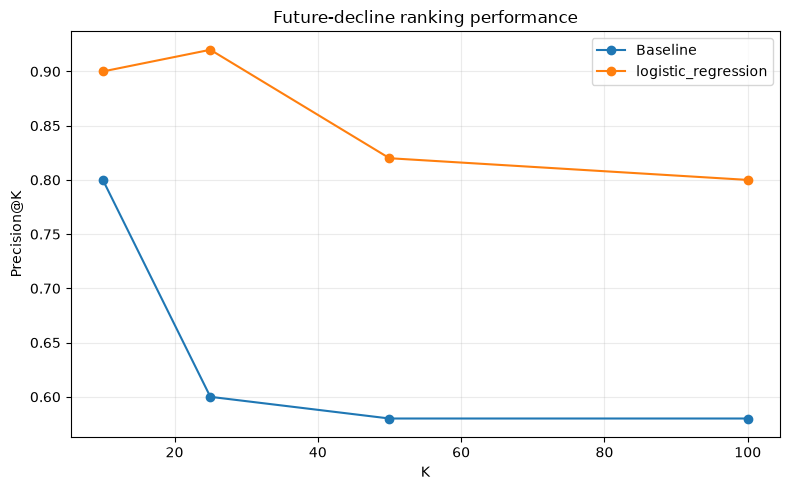

In [7]:
# Main result chart.
ks = [10,25,50,100]
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ks,[baseline_metrics[f"Precision@{k}"] for k in ks],marker="o",label="Baseline")
ax.plot(ks,[precision_at_k(y_test,best_p,k) for k in ks],marker="o",label=best_name)
ax.set_xlabel("K"); ax.set_ylabel("Precision@K")
ax.set_title("Future-decline ranking performance")
ax.grid(alpha=.25); ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature interpretation

Feature importance is descriptive, not causal. It tells us which historical signals the fitted model used most, not which signals cause future decline.

In [8]:
if best_name == "random_forest":
    rf = models["random_forest"]
    importance = pd.DataFrame({
        "feature": FEATURES,
        "importance": rf.feature_importances_
    }).sort_values("importance",ascending=False).head(15)
    display(importance)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.barh(importance.feature[::-1],importance.importance[::-1])
    ax.set_title("Top model features")
    ax.set_xlabel("Random Forest importance")
    plt.tight_layout()
    plt.show()

In [9]:
# Error analysis.
err = test[["client_hash_id","content_hash_id","month","future_decline",
            "p1_imp","p1_clicks","p1_pos","imp_change_1m",
            "click_change_1m","position_change_1m"]].copy()
err["score"] = best_p
err["predicted_decline"] = (best_p >= .5).astype(int)
err["error_type"] = np.select([
    (err.predicted_decline==1)&(err.future_decline==0),
    (err.predicted_decline==0)&(err.future_decline==1)
],["false_positive","false_negative"],default="correct")

print(err.error_type.value_counts())
display(err[err.error_type=="false_positive"].sort_values("score",ascending=False).head(10))
display(err[err.error_type=="false_negative"].sort_values("score").head(10))

error_type
correct           100703
false_negative     65072
false_positive     37395
Name: count, dtype: int64


,client_hash_id,content_hash_id,month,future_decline,p1_imp,p1_clicks,p1_pos,imp_change_1m,click_change_1m,position_change_1m,score,predicted_decline,error_type
1460929,client_e547b89c05043229,content_fff3da2dddec56d0,2026-03-01,0,2023.0,3.0,4.971824,-0.989287,-0.993228,-0.982164,0.999981,1,false_positive
1800274,client_e547b89c05043229,content_c9a0c2fdbdbfb562,2026-04-01,0,65681.0,739.0,2.372223,-0.538157,-0.539564,0.465343,0.999974,1,false_positive
1564172,client_73cda7b4e4f265ea,content_e241d6415ac9e534,2026-03-01,0,164152.0,401.0,3.022467,-0.192277,-0.215264,-0.357353,0.999601,1,false_positive
2309553,client_62f4a7e64f5e0096,content_f107e54b10b43725,2026-05-01,0,213514.0,661.0,4.108827,0.089374,-0.336345,0.929803,0.999220,1,false_positive
2194252,client_73cda7b4e4f265ea,content_f43118e089ecc69a,2026-05-01,0,175750.0,182.0,5.883846,0.260607,-0.047120,0.541628,0.998342,1,false_positive
1543478,client_e547b89c05043229,content_ec2e0346994fb5a5,2026-03-01,0,119854.0,490.0,2.555576,-0.169998,-0.100917,0.078124,0.997484,1,false_positive
1479955,client_62f4a7e64f5e0096,content_acbcc847f8996314,2026-03-01,0,148256.0,239.0,3.898392,0.300138,0.707143,-0.418057,0.997226,1,false_positive
2425124,client_73cda7b4e4f265ea,content_85703b835ab9e744,2026-05-01,0,115430.0,736.0,3.490990,-0.044991,-0.325390,0.720166,0.997032,1,false_positive
1794373,client_23a62021009f63c4,content_e8a52cf3d5988c07,2026-04-01,0,244931.0,669.0,15.173490,0.510717,0.066986,1.589078,0.996802,1,false_positive
2412232,client_73cda7b4e4f265ea,content_6302b8bce0bb84cb,2026-05-01,0,116949.0,219.0,3.456601,0.046392,-0.400000,0.362053,0.996442,1,false_positive


,client_hash_id,content_hash_id,month,future_decline,p1_imp,p1_clicks,p1_pos,imp_change_1m,click_change_1m,position_change_1m,score,predicted_decline,error_type
2034651,client_e547b89c05043229,content_1e921148b5fee86a,2026-04-01,1,34215.0,59.0,4.076019,0.138943,1.132075e-01,-0.379192,0.000508,0,false_negative
1943885,client_e547b89c05043229,content_3bf07141cf1aa743,2026-04-01,1,5135.0,8.0,3.336904,-0.441726,-4.285714e-01,0.103375,0.002211,0,false_negative
1607310,client_23a62021009f63c4,content_469512b149928d3e,2026-03-01,1,1051.0,0.0,15.254044,1.472941,0.000000e+00,5.150514,0.008889,0,false_negative
1847807,client_e547b89c05043229,content_fff3da2dddec56d0,2026-04-01,1,5879.0,17.0,5.000170,1.906080,4.666665e+00,0.028346,0.012403,0,false_negative
1842062,client_e547b89c05043229,content_2e6f70bef2a448dd,2026-04-01,1,4076.0,3.0,1.169774,-0.234266,-4.999999e-01,0.887978,0.047183,0,false_negative
1587860,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,2026-03-01,1,195648.0,1.0,0.009865,3008.969184,1.000000e+06,-24.113212,0.052997,0,false_negative
2236810,client_73cda7b4e4f265ea,content_c9f840183215651b,2026-05-01,1,517.0,0.0,26.980658,-0.975975,0.000000e+00,21.633476,0.072328,0,false_negative
2269427,client_1a730cb2640a1abf,content_03ab3ff420b4988f,2026-05-01,1,1450.0,12.0,6.434483,1448.998551,1.200000e+07,6.434483,0.108602,0,false_negative
1711860,client_e547b89c05043229,content_0a90247658bf1056,2026-04-01,1,1913.0,2.0,5.603241,-0.525546,-4.999999e-01,3.482457,0.108764,0,false_negative
2344848,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,2026-05-01,1,188.0,0.0,11.170213,-0.997757,-9.999990e-01,11.054210,0.114098,0,false_negative


## 7. Threshold sensitivity

The 20% target is an operational choice. We test 10%, 20%, and 30% future-impression decline thresholds on the same temporal test rows.

In [10]:
sens = []
for d in [.10,.20,.30]:
    yy = (test.f1_imp < (1-d)*test.p1_imp).astype(int)
    sens.append({
        "decline_threshold":d,
        "test_base_rate":yy.mean(),
        "Precision@50":precision_at_k(yy,best_p,50),
        "Precision@100":precision_at_k(yy,best_p,100)
    })
sensitivity = pd.DataFrame(sens)
display(sensitivity)

,decline_threshold,test_base_rate,Precision@50,Precision@100
0,0.1,0.702820,0.90,0.86
1,0.2,0.651238,0.82,0.80
2,0.3,0.592336,0.78,0.75


## 8. Ranked recommendations

The final operational queue is generated after evaluation by fitting the selected model on all eligible historical rows and scoring the latest available prediction month.

Actions are decision-support labels:

- **refresh_review:** highest-risk items with meaningful historical visibility
- **priority_review:** moderate/high risk requiring manual investigation
- **monitor:** lower-risk items

These labels do not imply that the action will cause recovery.

In [11]:
final_model = models[best_name]
final_model.fit(data[FEATURES],data.future_decline.astype(int))

latest_month = data.month.max()
latest = data[data.month==latest_month].copy()
latest["risk_score"] = final_model.predict_proba(latest[FEATURES])[:,1]

latest["reason_code"] = np.select([
    (latest.risk_score>=.75)&(latest.imp_change_1m<0),
    (latest.risk_score>=.50)&(latest.position_change_1m>0),
    latest.risk_score>=.50
],[
    "high_risk_with_visibility_deterioration",
    "priority_review_position_deterioration",
    "priority_review"
],default="monitor")

latest["action"] = np.select([
    latest.risk_score>=.75,
    latest.risk_score>=.50
],["refresh_review","priority_review"],default="monitor")

queue = latest[[
    "client_hash_id","content_hash_id","month","risk_score","action","reason_code",
    "p1_imp","p1_clicks","p1_pos","imp_change_1m","click_change_1m","position_change_1m"
]].sort_values("risk_score",ascending=False).reset_index(drop=True)
queue.insert(0,"rank",np.arange(1,len(queue)+1))

display(queue.head(25))

,rank,client_hash_id,content_hash_id,month,risk_score,action,reason_code,p1_imp,p1_clicks,p1_pos,imp_change_1m,click_change_1m,position_change_1m
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,2026-05-01,1.000000,refresh_review,priority_review,799358.0,7434.0,2.237586,0.295296,0.311574,-0.093884
1,2,client_23a62021009f63c4,content_44f34c0a90047651,2026-05-01,0.999952,refresh_review,high_risk_with_visibility_deterioration,50335.0,15.0,8.170617,-0.763022,-0.375000,7.504740
2,3,client_e547b89c05043229,content_8d7d99f109e19aa2,2026-05-01,0.999823,refresh_review,high_risk_with_visibility_deterioration,191648.0,380.0,2.443965,-0.058227,0.314879,-0.024592
3,4,client_1a730cb2640a1abf,content_39e19a3ec2d95f9d,2026-05-01,0.999796,refresh_review,priority_review_position_deterioration,186872.0,2.0,9.445465,3.429821,-0.500000,0.442407
4,5,client_20259bd6705d81d4,content_82e35c4845e6c391,2026-05-01,0.999500,refresh_review,high_risk_with_visibility_deterioration,109367.0,19.0,25.107290,-0.240016,-0.683333,2.964010
5,6,client_62f4a7e64f5e0096,content_f6116743b00afc2d,2026-05-01,0.999413,refresh_review,high_risk_with_visibility_deterioration,18886.0,0.0,9.771947,-0.824453,-1.000000,0.036290
6,7,client_62f4a7e64f5e0096,content_34a70fea29d15f24,2026-05-01,0.999281,refresh_review,high_risk_with_visibility_deterioration,28278.0,84.0,3.906005,-0.802278,0.953488,0.739873
7,8,client_e547b89c05043229,content_0e03de7680314cd5,2026-05-01,0.999188,refresh_review,priority_review,305321.0,732.0,2.367040,0.379608,0.016667,-0.139060
8,9,client_23a62021009f63c4,content_164c1f53f13bcee1,2026-05-01,0.998957,refresh_review,high_risk_with_visibility_deterioration,78817.0,3.0,26.546976,-0.124080,0.500000,3.222867
9,10,client_9958f0a7ae1df715,content_cd3d932d4e1c8db0,2026-05-01,0.998827,refresh_review,high_risk_with_visibility_deterioration,13447.0,1.0,8.991597,-0.849472,-0.750000,1.159789


## 9. Public-safe interpretation

**Observed:** the model's measured ranking performance on the held-out future period.

**Directional:** feature importance and error patterns indicate which historical signal families were useful to this model.

**Decision-support:** the ranked queue identifies items for human review.

**Not claimed:** causal refresh impact, Google's ranking algorithm, guaranteed traffic recovery, or universal thresholds.

In [12]:
# Reproducibility receipts. Raw warehouse partitions are kept in the local HF cache, not in the repo.
# Locate the repository work/outputs directory from the notebook location.
here = Path.cwd().resolve()
repo_root = next((p for p in [here, *here.parents] if (p / "work").exists()), here)
out = repo_root / "work" / "outputs"
out.mkdir(parents=True,exist_ok=True)

results.to_csv(out/"future_model_results.csv",index=False)
sensitivity.to_csv(out/"future_threshold_sensitivity.csv",index=False)
queue.to_csv(out/"future_ranked_recommendations.csv",index=False)

payload = {
    "task":"future_content_performance_decline_ranking",
    "label":"next-month impressions < 80% of previous-month impressions",
    "feature_window":"previous three consecutive monthly observations",
    "test_months":[str(x) for x in test_months],
    "random_seed":42,
    "test_base_rate":float(y_test.mean()),
    "best_model":best_name,
    "metrics":results.to_dict(orient="records"),
    "threshold_sensitivity":sensitivity.to_dict(orient="records")
}
(out/"future_metrics.json").write_text(json.dumps(payload,indent=2),encoding="utf-8")

print("Artifacts written to:",out.resolve())

Artifacts written to: D:\GodCPP\fl1\FLrank1\work\outputs


In [13]:
lr = models["logistic_regression"]

coef = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": lr.named_steps["model"].coef_[0]
})

coef["abs_coefficient"] = coef["coefficient"].abs()

coef = (
    coef
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

display(coef)

,feature,coefficient,abs_coefficient
21,log_p1_clicks,-0.681848,0.681848
20,log_p1_imp,0.623581,0.623581
1,p2_imp,0.361008,0.361008
9,p1_days,-0.271918,0.271918
18,position_change_3m,0.210557,0.210557
2,p3_imp,-0.184945,0.184945
4,p2_clicks,-0.117306,0.117306
5,p3_clicks,0.103449,0.103449
8,p3_pos,-0.094197,0.094197
0,p1_imp,-0.081024,0.081024


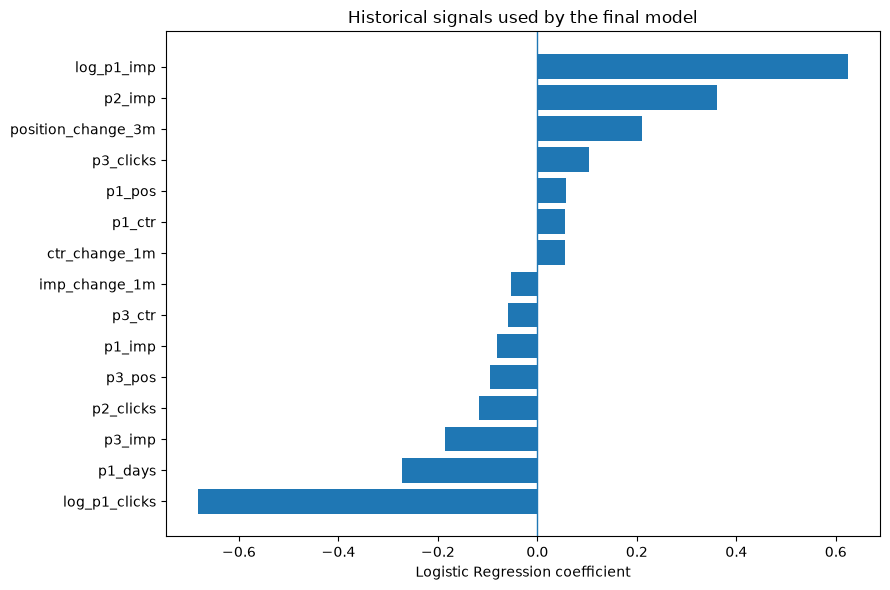

In [14]:
plot_df = coef.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["feature"], plot_df["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Logistic Regression coefficient")
ax.set_title("Historical signals used by the final model")
plt.tight_layout()
plt.show()

## 10. Five-minute demo

**0:00–0:45:** Research question and editorial decision.

**0:45–1:30:** Hugging Face Hub → monthly partitions → DuckDB aggregation → monthly panel.

**1:30–2:15:** Leakage-safe temporal design: previous 3 months as features, next month as label.

**2:15–3:15:** Baseline vs ML Precision@K and test base rate.

**3:15–4:15:** Feature importance and error analysis.

**4:15–5:00:** Ranked queue, limitations, and decision-support framing.

## Acknowledgments & data credit

Built on the **FlyRank ML Internship dataset**. Data credit: https://flyrank.ai

No client names, domains, URLs, private queries, credentials, or raw exports are published.

## Final self-check

- [ ] Monthly fact partitions fetched temporarily through Hugging Face Hub and aggregated with DuckDB; raw partitions deleted after aggregation and not committed.
- [ ] Features use only periods before the prediction point.
- [ ] Future month is used only for the label.
- [ ] `trend_direction` / `trend_pct` are not used.
- [ ] Pseudonymous IDs are not predictive features.
- [ ] Baseline and ML use the same temporal test set.
- [ ] Test base rate is reported next to Precision@K.
- [ ] Metrics JSON is committed as the reproducibility receipt.
- [ ] Error analysis and threshold sensitivity are included.
- [ ] Public outputs contain no client-identifying details.
- [ ] Paper claims use observed/measured/directional/decision-support language.
- [ ] `submission/paper_url.txt` is filled only after the paper is deployed.